In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from catboost import CatBoostRegressor, Pool
import math

In [4]:
# Функция для вычисления расстояния (Haversine formula)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
    c = 2 * math.asin(math.sqrt(a))
    distance = R * c
    return distance

In [6]:
data = pd.read_csv("AB_NYC_2019.csv/AB_NYC_2019.csv")
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [8]:
data.price.isnull().sum()

0

In [130]:
len(data.host_name.unique())

11017

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [12]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


Подготавливаем данные

In [67]:
# Фильтруем данные по 95-му процентилю
price_95th_percentile = data['price'].quantile(0.95)
data = data[(data['price'] > 0) & (data['price'] < price_95th_percentile)]

<Axes: >

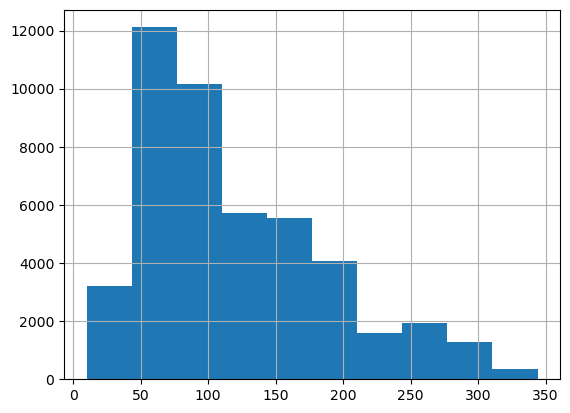

In [69]:
data.price.hist()

<Axes: >

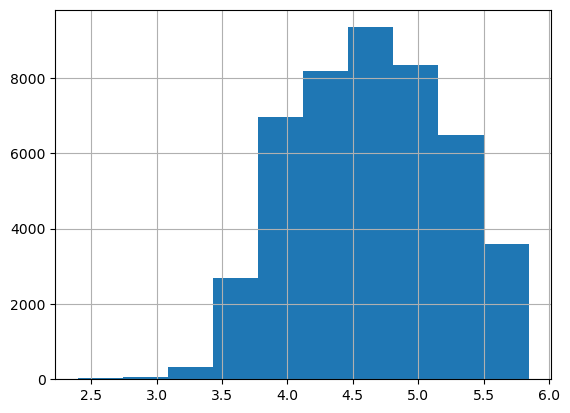

In [71]:
np.log1p(data.price).hist()

In [73]:
# Логарифмируем целевую переменную
data['log_price'] = np.log(data['price'])

<Axes: >

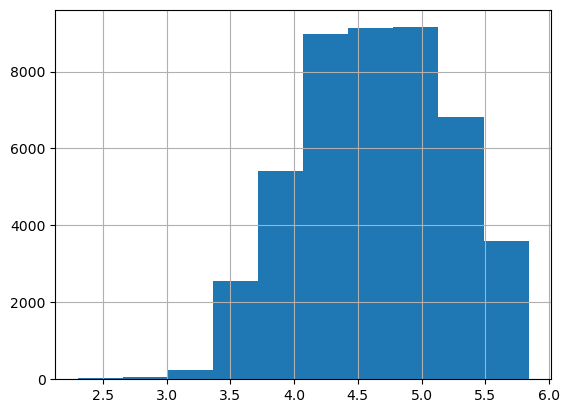

In [75]:
data['log_price'].hist()

Заполняем пропуски

In [77]:
data['last_review'] = data['last_review'].fillna(0)
data['reviews_per_month'] = data['reviews_per_month'].fillna(0)
data['name'] = data['name'].fillna('Unknown')
data['host_name'] = data['host_name'].fillna('Unknown')

In [79]:
# Добавляем признак — расстояние до центра Манхэттена
center_lat, center_lon = 40.7831, -73.9712
data['distance_to_center'] = data.apply(
    lambda row: haversine(row['latitude'], row['longitude'], center_lat, center_lon), axis=1
)

In [81]:
# Выбираем числовые признаки для корреляции
numeric_features = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 
                   'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 
                   'distance_to_center', 'log_price']

# Вычисляем матрицу корреляции
correlation_matrix = data[numeric_features].corr()

In [83]:
correlation_matrix

,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,distance_to_center,log_price
latitude,1.000000,0.091078,0.025982,-0.012530,-0.017842,0.021674,-0.017082,-0.727415,0.078420
longitude,0.091078,1.000000,-0.064388,0.053933,0.140323,-0.108099,0.096348,0.320973,-0.326631
minimum_nights,0.025982,-0.064388,1.000000,-0.082984,-0.127954,0.134420,0.146752,-0.065740,0.024632
number_of_reviews,-0.012530,0.053933,-0.082984,1.000000,0.593427,-0.070812,0.183022,0.040517,-0.008855
reviews_per_month,-0.017842,0.140323,-0.127954,0.593427,1.000000,-0.051577,0.170917,0.092594,-0.040723
calculated_host_listings_count,0.021674,-0.108099,0.134420,-0.070812,-0.051577,1.000000,0.226222,-0.078751,0.143662
availability_365,-0.017082,0.096348,0.146752,0.183022,0.170917,0.226222,1.000000,0.090705,0.049229
distance_to_center,-0.727415,0.320973,-0.065740,0.040517,0.092594,-0.078751,0.090705,1.000000,-0.297070
log_price,0.078420,-0.326631,0.024632,-0.008855,-0.040723,0.143662,0.049229,-0.297070,1.000000


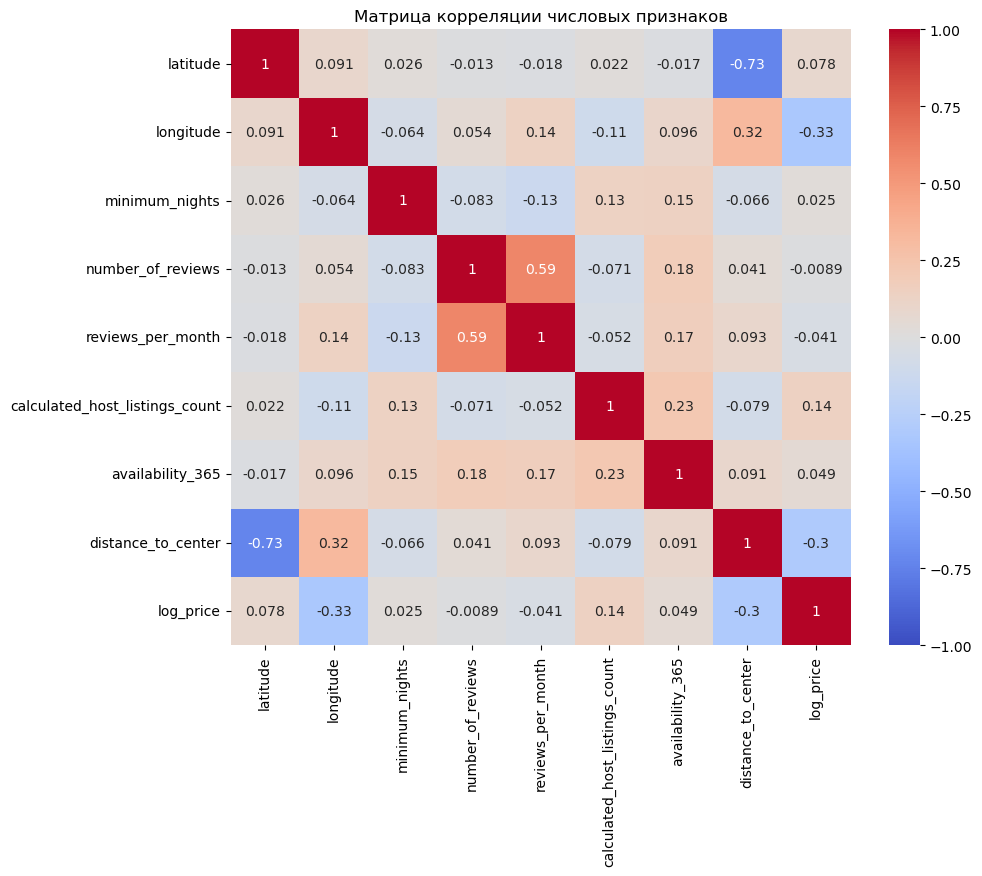

In [85]:
# Визуализация тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Матрица корреляции числовых признаков')
plt.show()

Создаем модель

In [88]:
# Определяем признаки для модели
features = ['neighbourhood_group', 'neighbourhood', 'room_type', 'latitude', 'longitude', 'minimum_nights',
            'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
            'availability_365', 'distance_to_center']
categorical_features = ['neighbourhood_group', 'neighbourhood', 'room_type']
X = data[features]
y = data['log_price']

In [137]:
# Разделяем данные на обучающую (70%), валидационную (15%) и тестовую выборки (15%)
X_train, X_test_val, y_train, y_test_val = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=0.5, random_state=42)

# Создаем Pool для CatBoost
train_pool = Pool(X_train, y_train, cat_features=categorical_features)
val_pool = Pool(X_val, y_val, cat_features=categorical_features)
test_pool = Pool(X_test, y_test, cat_features=categorical_features)

In [199]:
# Определяем модель CatBoost
model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.05,
    depth=8,
    #l2_leaf_reg=1,
    random_seed=42,
    loss_function='RMSE',
    #eval_metric='MAE',
    verbose=100,
    task_type='GPU'
)

Подбор пораметров кросс-валидацией

In [141]:
# Задаем сетку гиперпараметров для поиска
param_grid = {
    'depth': [4, 6, 8],
    'l2_leaf_reg': [0, 1, 3]
}

In [150]:
# Выполняем поиск гиперпараметров
grid_search_result = model.grid_search(
    param_grid,
    train_pool,
    cv=3,
    partition_random_seed=42,
    plot=True,
    verbose=False
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 4.4334465	test: 4.4339266	best: 4.4339266 (0)	total: 18.7ms	remaining: 28.1s
200:	learn: 0.3491399	test: 0.3523690	best: 0.3523690 (200)	total: 3.84s	remaining: 24.8s
400:	learn: 0.3445781	test: 0.3493507	best: 0.3493507 (400)	total: 7.71s	remaining: 21.1s
600:	learn: 0.3421720	test: 0.3482689	best: 0.3482683 (596)	total: 11.7s	remaining: 17.4s
800:	learn: 0.3407225	test: 0.3476364	best: 0.3476364 (800)	total: 15.6s	remaining: 13.6s
1000:	learn: 0.3396289	test: 0.3472567	best: 0.3472545 (998)	total: 19.5s	remaining: 9.73s
1200:	learn: 0.3387636	test: 0.3469696	best: 0.3469672 (1192)	total: 23.6s	remaining: 5.88s
1400:	learn: 0.3382892	test: 0.3468719	best: 0.3468608 (1304)	total: 27.7s	remaining: 1.96s
1499:	learn: 0.3379122	test: 0.3466833	best: 0.3466833 (1497)	total: 29.8s	remaining: 0us
bestTest = 0.3466832838
bestIteration = 1497
0:	learn: 4.4335019	test: 4.4339802	best: 4.4339802 (0)	total: 18.4ms	remaining: 27.7s
200:	learn: 0.3493549	test: 0.3523977	best: 0.3523975 (1

In [153]:
# Выводим лучшие гиперпараметры
print("Лучшие гиперпараметры:", grid_search_result['params'])

Лучшие гиперпараметры: {'depth': 8, 'l2_leaf_reg': 0}


Обучаем модель

In [201]:
model.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=100,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.5639517	test: 0.5658948	best: 0.5658948 (0)	total: 46.2ms	remaining: 1m 9s
100:	learn: 0.3458404	test: 0.3556440	best: 0.3556437 (99)	total: 4.92s	remaining: 1m 8s
200:	learn: 0.3411822	test: 0.3525475	best: 0.3525475 (200)	total: 9s	remaining: 58.1s
300:	learn: 0.3387822	test: 0.3512256	best: 0.3512256 (300)	total: 12.9s	remaining: 51.3s
400:	learn: 0.3367322	test: 0.3502401	best: 0.3502355 (398)	total: 16.5s	remaining: 45.3s
500:	learn: 0.3350961	test: 0.3496248	best: 0.3496248 (500)	total: 20.4s	remaining: 40.6s
600:	learn: 0.3336867	test: 0.3492942	best: 0.3492942 (600)	total: 24.9s	remaining: 37.3s
700:	learn: 0.3329664	test: 0.3490387	best: 0.3490382 (697)	total: 29.2s	remaining: 33.3s
800:	learn: 0.3319806	test: 0.3487503	best: 0.3487500 (798)	total: 33.9s	remaining: 29.6s
900:	learn: 0.3313612	test: 0.3486267	best: 0.3486190 (898)	total: 38.1s	remaining: 25.4s
1000:	learn: 0.3309059	test: 0.3484486	best: 0.3484486 (1000)	total: 42.2s	remaining: 21s
1100:	learn: 0.33

In [203]:
# Оцениваем модель
y_pred_log = model.predict(test_pool)

y_pred = np.exp(y_pred_log)
y_test_actual = np.exp(y_test)
rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae_test_actual = mean_absolute_error(y_test_actual, y_pred)
mape_test_actual = mean_absolute_percentage_error(y_test_actual, y_pred) * 100
print(f"RMSE на тестовой выборке (оригинальная цена): {rmse_actual}")
print(f"MAE на тестовой выборке (оригинальная цена): {mae_test_actual}")
print(f"MAPE на тестовой выборке (оригинальная цена): {mape_test_actual}%")

RMSE на тестовой выборке (оригинальная цена): 44.82994379343439
MAE на тестовой выборке (оригинальная цена): 30.731861061094335
MAPE на тестовой выборке (оригинальная цена): 26.515584902164075%


In [205]:
# Важность признаков
feature_importances = pd.DataFrame({
    'feature': features,
    'importance': model.get_feature_importance()
}).sort_values(by='importance', ascending=False)
print("\nВажность признаков:")
print(feature_importances)


Важность признаков:
                           feature  importance
2                        room_type   57.569960
4                        longitude    7.112315
9                 availability_365    5.861850
10              distance_to_center    5.491759
5                   minimum_nights    5.274936
3                         latitude    4.831898
0              neighbourhood_group    3.807615
8   calculated_host_listings_count    3.787664
1                    neighbourhood    2.243834
6                number_of_reviews    2.106882
7                reviews_per_month    1.911288


In [207]:
y_pred.size

6895

In [209]:
y_test_actual

23706     50.0
29751     45.0
39265     80.0
10370     50.0
23098    180.0
         ...  
2328     199.0
38512     85.0
28067     50.0
34747     50.0
39369    165.0
Name: log_price, Length: 6895, dtype: float64

In [211]:
result = {'predicted_price': y_pred, 'actual_price': y_test_actual}
result_df = pd.DataFrame(result)

In [213]:
result_df

,predicted_price,actual_price
23706,32.081827,50.0
29751,57.371679,45.0
39265,93.224233,80.0
10370,55.201404,50.0
23098,178.563659,180.0
...,...,...
2328,201.152599,199.0
38512,81.793508,85.0
28067,113.024675,50.0
34747,60.728549,50.0


Выводы: убрав значения price в 0 и за пределами 95% наблюдений, получили выборку, в которой price < 500. В таком случае метрика RMSE показывает себя сильно лучше, чем при обучении на всех данных (44 против 250), однако модель не способна предсказывать высокие значения price (мало данных имеющих высокий price в данном датасете). Так же добавлен признак удаленности от центра, который неплохо проявил себя.